In [1]:
# Cell 1: Imports
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Cell 2: Paths and configuration

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "customer-support-on-twitter"
FULL_CSV = RAW_DIR / "twcs.csv"

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
RUNS_DIR = PROJECT_ROOT / "runs" / "brand_selection"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

for directory in [INTERIM_DIR, RUNS_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Thread-preserving sampling configuration.
SAMPLE_ROOTS_FRACTION = 0.15
SAMPLE_SEED = 42

# Number of top candidate brands considered in downstream scoring.
TOP_N_BRANDS = 25

# IMPORTANT:
# Intermediate DataFrames are stored with pickle.
THREADS_SAMPLE_PATH = INTERIM_DIR / "threads_sample.pkl"
SAMPLE_METADATA_PATH = RUNS_DIR / "sample_metadata.json"

# Set False when you intentionally want to rebuild the sample.
USE_CACHED_THREADS_SAMPLE = True

print("Project root:", PROJECT_ROOT)
print("Full dataset:", FULL_CSV)
print("Exists:", FULL_CSV.exists())
print("Cached thread sample:", THREADS_SAMPLE_PATH)
print("Cache exists:", THREADS_SAMPLE_PATH.exists())
print("TOP_N_BRANDS:", TOP_N_BRANDS)

Project root: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ
Full dataset: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\data\raw\customer-support-on-twitter\twcs.csv
Exists: True
Cached thread sample: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\data\interim\threads_sample.pkl
Cache exists: True
TOP_N_BRANDS: 25


In [3]:
# Cell 3: Inline visualization helper functions
def show_bar(series, title, xlabel, ylabel, top_n=20, figsize=(12, 6), rotate=45, color="viridis"):
    """Plot a horizontal or vertical bar chart inline and return the figure."""
    data = series.head(top_n) if top_n else series
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=data.values, y=data.index.astype(str), palette=color, ax=ax)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(data.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

def show_hist(series, title, xlabel, ylabel="Frequency", bins=50, figsize=(12, 6), log_y=False):
    """Plot a histogram inline and return the figure."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(series.dropna(), bins=bins, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if log_y:
        ax.set_yscale("log")
    plt.tight_layout()
    plt.show()
    return fig

def show_pie(series, title, top_n=10, figsize=(10, 8)):
    """Plot a pie chart inline for a categorical series."""
    data = series.head(top_n)
    other = series.iloc[top_n:].sum()
    if other > 0:
        data = pd.concat([data, pd.Series({"Other": other})])
    fig, ax = plt.subplots(figsize=figsize)
    ax.pie(data.values, labels=data.index.astype(str), autopct="%1.1f%%",
           startangle=140, colors=sns.color_palette("viridis", len(data)))
    ax.set_title(title, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
    return fig

def show_heatmap(df, title, figsize=(14, 8), cmap="viridis", annot=True, fmt=".2f"):
    """Plot a heatmap inline."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df, cmap=cmap, annot=annot, fmt=fmt, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
    return fig

def save_fig(fig, name):
    """Save figure to reports/figures."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=140)
    print(f"Saved: {path}")

print("Helper functions ready.")

Helper functions ready.


In [4]:
# Cell 4: Load dataset with THREAD-PRESERVING sampling
#
# We reconstruct root_id on the FULL dataset first, then sample complete
# conversation roots. Sampling individual tweets is intentionally avoided.

COLS = [
    "tweet_id",
    "author_id",
    "inbound",
    "created_at",
    "text",
    "response_tweet_id",
    "in_response_to_tweet_id",
]


def normalize_inbound(series: pd.Series) -> pd.Series:
    """Normalize common CSV representations of the inbound flag."""
    if pd.api.types.is_bool_dtype(series):
        return series

    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int).astype(bool)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "yes": True,
            "no": False,
        })
    )

    if normalized.isna().any():
        bad = series[normalized.isna()].dropna().unique()[:10]
        raise ValueError(f"Could not normalize inbound values: {bad}")

    return normalized.astype(bool)


def build_parent_map(frame: pd.DataFrame) -> dict[int, int]:
    """Build child_tweet_id -> parent_tweet_id mapping."""
    tweet_ids = pd.to_numeric(frame["tweet_id"], errors="coerce")
    parent_ids = pd.to_numeric(
        frame["in_response_to_tweet_id"],
        errors="coerce",
    )

    return {
        int(tid): int(pid)
        for tid, pid in zip(tweet_ids, parent_ids)
        if pd.notna(tid) and pd.notna(pid)
    }


def build_root_resolver(parent_map: dict[int, int]):
    """
    Resolve each tweet to the root reached by following parent links.

    Missing parents are intentionally retained in the root chain; the caller
    later filters to roots that are actual inbound tweets present in the data.
    """
    cache: dict[int, int] = {}

    def get_root(tweet_id: int) -> int:
        if tweet_id in cache:
            return cache[tweet_id]

        path = []
        seen = set()
        current = tweet_id

        while current in parent_map and current not in seen:
            if current in cache:
                root = cache[current]
                break

            seen.add(current)
            path.append(current)
            current = parent_map[current]
        else:
            root = current

        for node in path:
            cache[node] = root

        return root

    return get_root


def build_thread_preserving_sample(
    path: Path,
    fraction: float,
    seed: int,
) -> tuple[pd.DataFrame, dict]:
    """Load full data, reconstruct roots, then sample complete root threads."""
    print(f"Loading full dataset:\n  {path}")

    full = pd.read_csv(
        path,
        usecols=COLS,
        encoding="utf-8",
        low_memory=False,
    )

    print(f"Loaded {len(full):,} tweets")

    full["inbound"] = normalize_inbound(full["inbound"])
    full["tweet_id"] = pd.to_numeric(
        full["tweet_id"],
        errors="raise",
    ).astype("int64")

    full["in_response_to_tweet_id"] = pd.to_numeric(
        full["in_response_to_tweet_id"],
        errors="coerce",
    ).astype("Int64")

    full["created_at"] = pd.to_datetime(
        full["created_at"],
        errors="coerce",
        utc=True,
    )

    # Reconstruct conversation roots on the COMPLETE dataset.
    parent_map = build_parent_map(full)
    get_root = build_root_resolver(parent_map)

    full["root_id"] = [
        get_root(int(tweet_id))
        for tweet_id in full["tweet_id"].to_numpy()
    ]

    inbound_root_ids = set(
        full.loc[full["inbound"], "tweet_id"].astype("int64")
    )

    full["valid_thread"] = full["root_id"].isin(inbound_root_ids)

    valid = full.loc[full["valid_thread"]].copy()

    total_roots = valid["root_id"].nunique()

    if total_roots == 0:
        raise RuntimeError(
            "No inbound-rooted threads were reconstructed."
        )

    # Sample COMPLETE ROOTS.
    rng = np.random.default_rng(seed)

    all_roots = valid["root_id"].drop_duplicates().to_numpy()
    n_keep = max(
        1,
        min(
            len(all_roots),
            int(round(len(all_roots) * fraction)),
        ),
    )

    sampled_roots = rng.choice(
        all_roots,
        size=n_keep,
        replace=False,
    )

    sampled_root_set = set(
        int(x) for x in sampled_roots
    )

    sampled = valid.loc[
        valid["root_id"].isin(sampled_root_set)
    ].copy()

    sampled = sampled.sort_values(
        ["root_id", "created_at", "tweet_id"],
        kind="stable",
    ).reset_index(drop=True)

    meta = {
        "source": str(path),
        "sampling_strategy": "thread_preserving_root_sampling",
        "fraction_of_roots": float(fraction),
        "seed": int(seed),
        "total_tweets_full": int(len(full)),
        "total_roots_full": int(total_roots),
        "sampled_roots": int(len(sampled_roots)),
        "sampled_tweets": int(len(sampled)),
        "sampled_threads": int(sampled["root_id"].nunique()),
        "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    }

    return sampled, meta


if USE_CACHED_THREADS_SAMPLE and THREADS_SAMPLE_PATH.exists():
    print(f"Loading cached pickle sample:\n  {THREADS_SAMPLE_PATH}")
    df = pd.read_pickle(THREADS_SAMPLE_PATH)

    with open(
        SAMPLE_METADATA_PATH,
        "r",
        encoding="utf-8",
    ) as f:
        sample_meta = json.load(f)

else:
    df, sample_meta = build_thread_preserving_sample(
        FULL_CSV,
        SAMPLE_ROOTS_FRACTION,
        SAMPLE_SEED,
    )

    df.to_pickle(THREADS_SAMPLE_PATH)

    with open(
        SAMPLE_METADATA_PATH,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            sample_meta,
            f,
            indent=2,
            default=str,
        )

print("\nSample metadata:")
print(json.dumps(sample_meta, indent=2, default=str))

print("\nShape:", df.shape)
display(df.head())


Loading cached pickle sample:
  d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\data\interim\threads_sample.pkl

Sample metadata:
{
  "source": "d:\\CODIN PLAYGROUND\\ML-AI\\ResolveIQ\\data\\raw\\customer-support-on-twitter\\twcs.csv",
  "sampling_strategy": "thread_preserving_root_sampling",
  "fraction_of_roots": 0.15,
  "seed": 42,
  "total_tweets_full": 2811774,
  "total_roots_full": 787346,
  "sampled_roots": 118101,
  "sampled_tweets": 405766,
  "sampled_threads": 118101,
  "timestamp": "2026-09-11T20:15:12.115787+00:00"
}

Shape: (405766, 9)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,root_id,valid_thread
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further as...,2,3.0,8,True
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,8,True
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0,8,True
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your ...,3,5.0,8,True
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,8,True


In [5]:
# Cell 5: Basic structure and dtypes
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()
print(df.dtypes)
print()
df.info(memory_usage="deep")

DATASET OVERVIEW
Rows: 405,766
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'root_id', 'valid_thread']

tweet_id                     int64
author_id                      str
inbound                       bool
created_at                     str
text                           str
response_tweet_id              str
in_response_to_tweet_id    float64
root_id                      int64
valid_thread                  bool
dtype: object

<class 'pandas.DataFrame'>
Index: 405766 entries, 0 to 2811768
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   tweet_id                 405766 non-null  int64  
 1   author_id                405766 non-null  str    
 2   inbound                  405766 non-null  bool   
 3   created_at               405766 non-null  str    
 4   text                     405766 non-null  str    
 5   response_t

,missing,pct
response_tweet_id,150842,37.17
in_response_to_tweet_id,118101,29.11
tweet_id,0,0.00
author_id,0,0.00
inbound,0,0.00
text,0,0.00
created_at,0,0.00
root_id,0,0.00
valid_thread,0,0.00


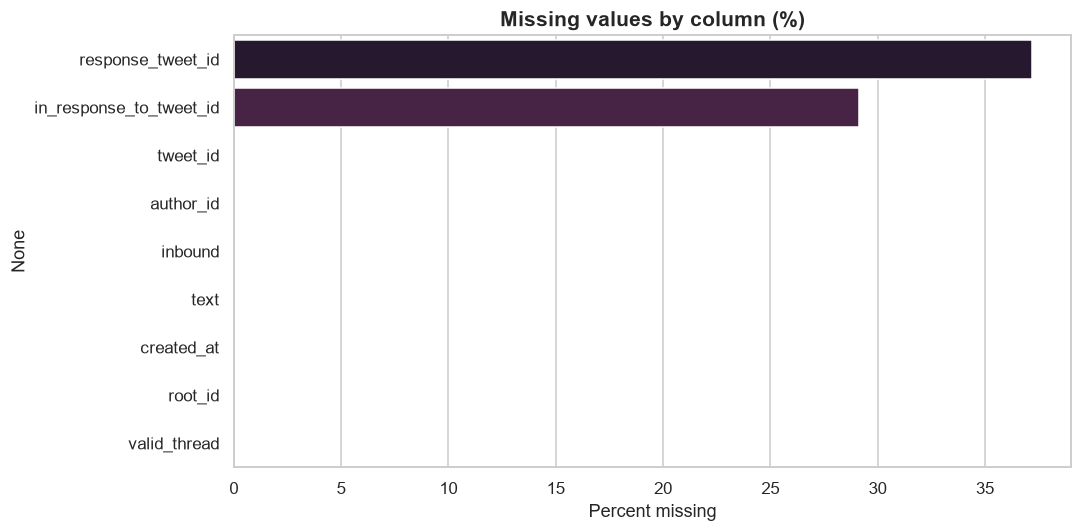

In [6]:
# Cell 6: Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
display(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=missing_df["pct"].values, y=missing_df.index, palette="rocket", ax=ax)
ax.set_title("Missing values by column (%)", fontsize=14, weight="bold")
ax.set_xlabel("Percent missing")
plt.tight_layout()
plt.show()

inbound
Inbound (customer)    221790
Outbound (brand)      183976
Name: count, dtype: int64


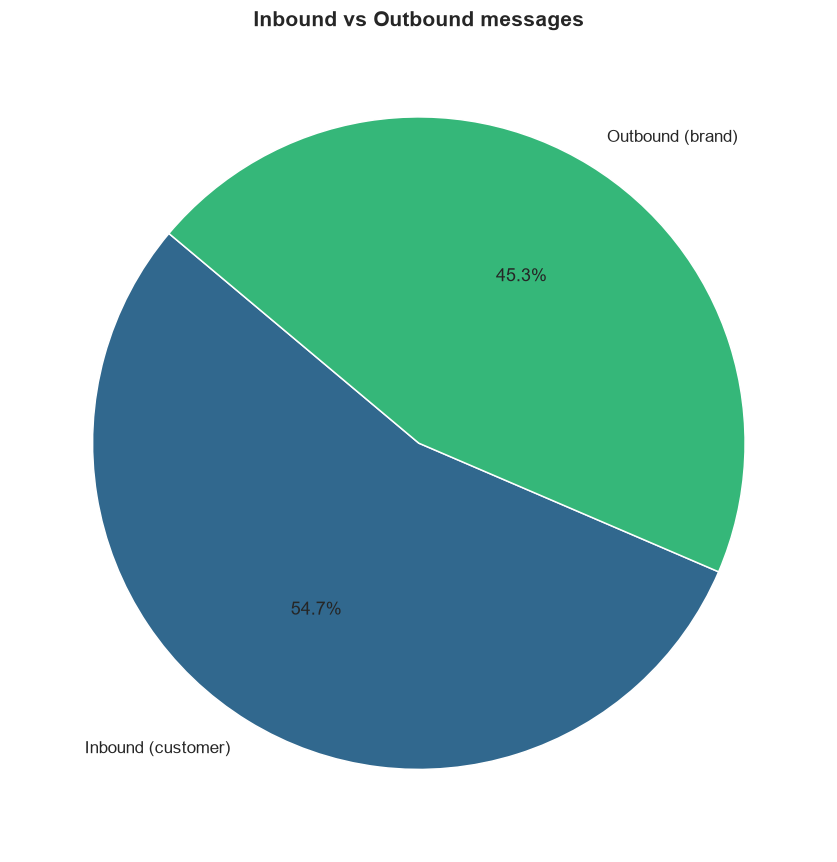

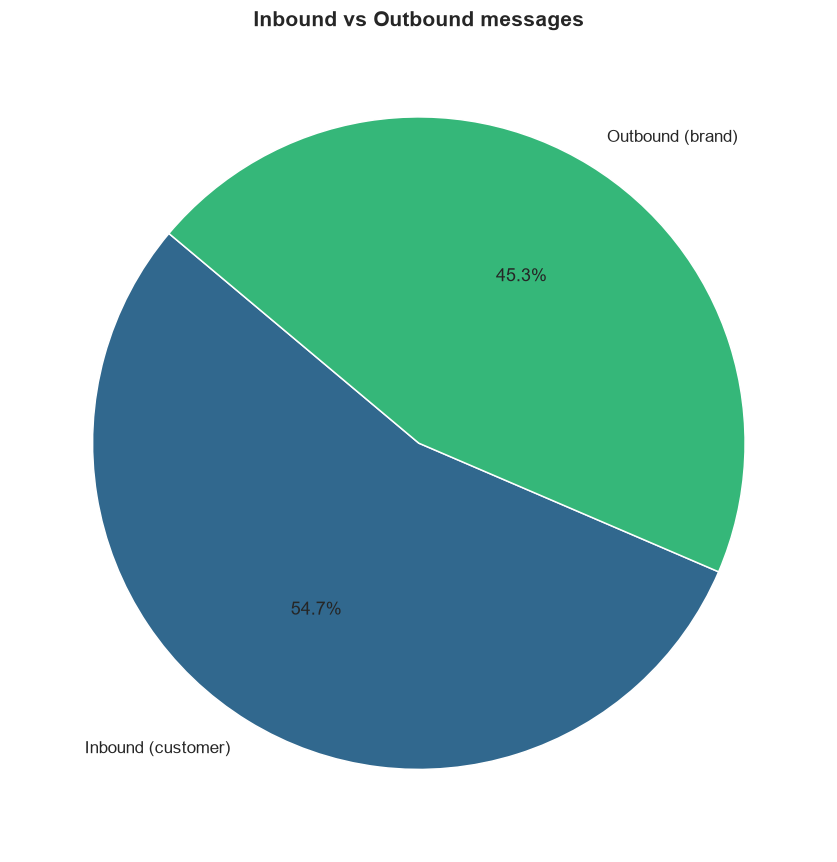

In [7]:
# Cell 7: Inbound vs outbound distribution
inbound_counts = df["inbound"].value_counts().rename({True: "Inbound (customer)", False: "Outbound (brand)"})
print(inbound_counts)
show_pie(inbound_counts, "Inbound vs Outbound messages", top_n=5)

Unique authors: 122,770

Top 30 authors by tweet volume:


author_id
AmazonHelp         24775
AppleSupport       16065
Uber_Support        8293
SpotifyCares        6505
Delta               6458
Tesco               5638
AmericanAir         5289
comcastcares        4924
TMobileHelp         4911
British_Airways     4304
SouthwestAir        4162
VirginTrains        3662
Ask_Spectrum        3613
XboxSupport         3440
hulu_support        3216
sprintcare          3125
sainsburys          2921
GWRHelp             2794
ChipotleTweets      2650
AskPlayStation      2577
UPSHelp             2549
VerizonSupport      2485
ATVIAssist          2351
idea_cares          2254
O2                  2101
Safaricom_Care      2037
AskTarget           1947
AirAsiaSupport      1797
AskLyft             1794
BofA_Help           1788
Name: count, dtype: int64

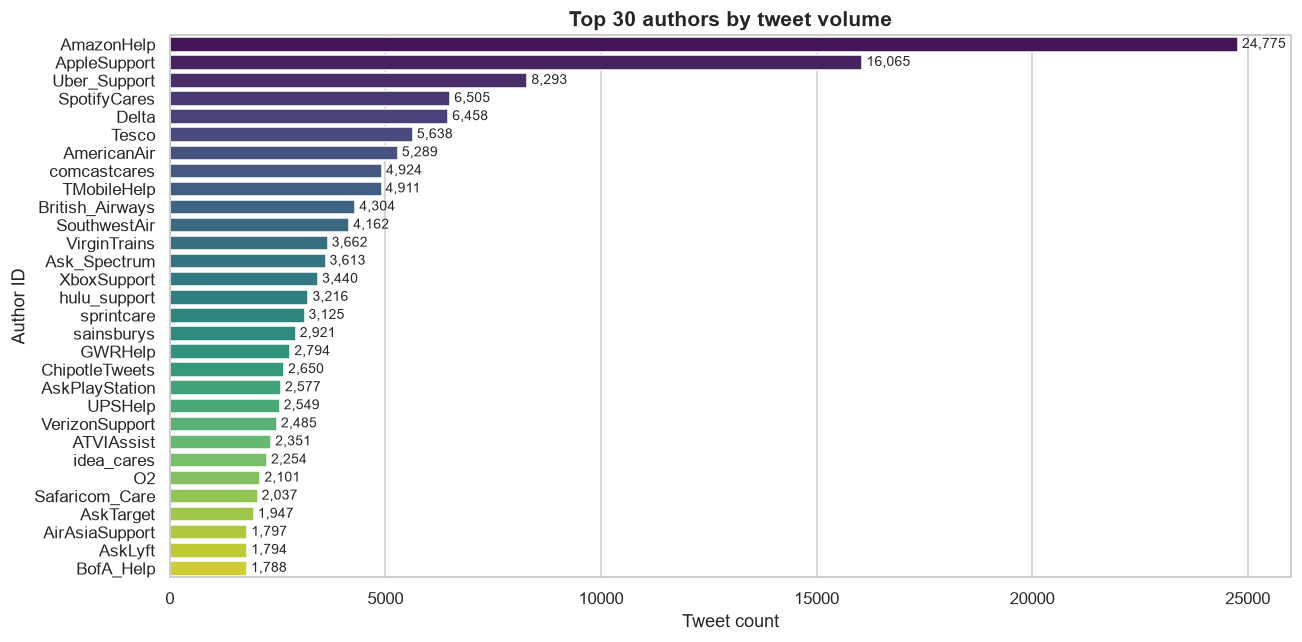

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\top_authors_volume.png


In [8]:
# Cell 8: Brand exploration — who are the top authors by volume?
author_counts = df["author_id"].value_counts()
print(f"Unique authors: {author_counts.shape[0]:,}")
print("\nTop 30 authors by tweet volume:")
display(author_counts.head(30))

top_authors = author_counts.head(30)
fig = show_bar(top_authors, "Top 30 authors by tweet volume", "Tweet count", "Author ID", top_n=30)
save_fig(fig, "top_authors_volume")

Unique brand-side authors: 108

Top 30 brand-side authors:


author_id
AmazonHelp         24775
AppleSupport       16065
Uber_Support        8293
SpotifyCares        6505
Delta               6458
Tesco               5638
AmericanAir         5289
comcastcares        4924
TMobileHelp         4911
British_Airways     4304
SouthwestAir        4162
VirginTrains        3662
Ask_Spectrum        3613
XboxSupport         3440
hulu_support        3216
sprintcare          3125
sainsburys          2921
GWRHelp             2794
ChipotleTweets      2650
AskPlayStation      2577
UPSHelp             2549
VerizonSupport      2485
ATVIAssist          2351
idea_cares          2254
O2                  2101
Safaricom_Care      2037
AskTarget           1947
AirAsiaSupport      1797
AskLyft             1794
BofA_Help           1788
Name: count, dtype: int64

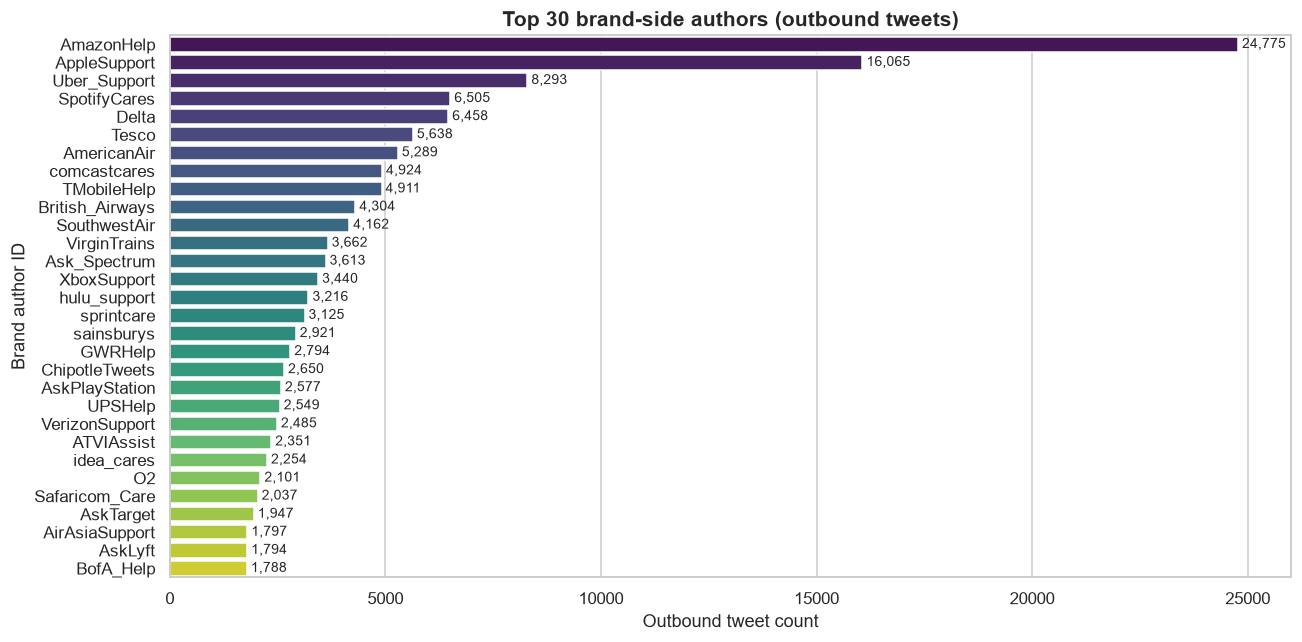

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\top_brand_authors.png


In [9]:
# Cell 9: Brand identification — brands usually have high outbound volume and recognizable IDs
# In TWCS, brands are the accounts that respond to inbound tweets.
# Identify candidate brands as authors with many outbound (inbound == False) messages.
outbound = df[df["inbound"] == False]
inbound = df[df["inbound"] == True]

brand_outbound_counts = outbound["author_id"].value_counts()
print(f"Unique brand-side authors: {brand_outbound_counts.shape[0]:,}")
print("\nTop 30 brand-side authors:")
display(brand_outbound_counts.head(30))

fig = show_bar(brand_outbound_counts.head(30), "Top 30 brand-side authors (outbound tweets)",
               "Outbound tweet count", "Brand author ID", top_n=30)
save_fig(fig, "top_brand_authors")

Unique brand-side authors: 108

Top 25 brands by outbound volume:


,outbound_tweets,n_threads,unique_customers
author_id,,,
AmazonHelp,24775,12262,12510
AppleSupport,16065,12190,12975
Uber_Support,8293,6255,6512
SpotifyCares,6505,4236,4519
Delta,6458,4039,4119
Tesco,5638,2468,2619
AmericanAir,5289,3871,4071
comcastcares,4924,3624,3933
TMobileHelp,4911,3323,3785


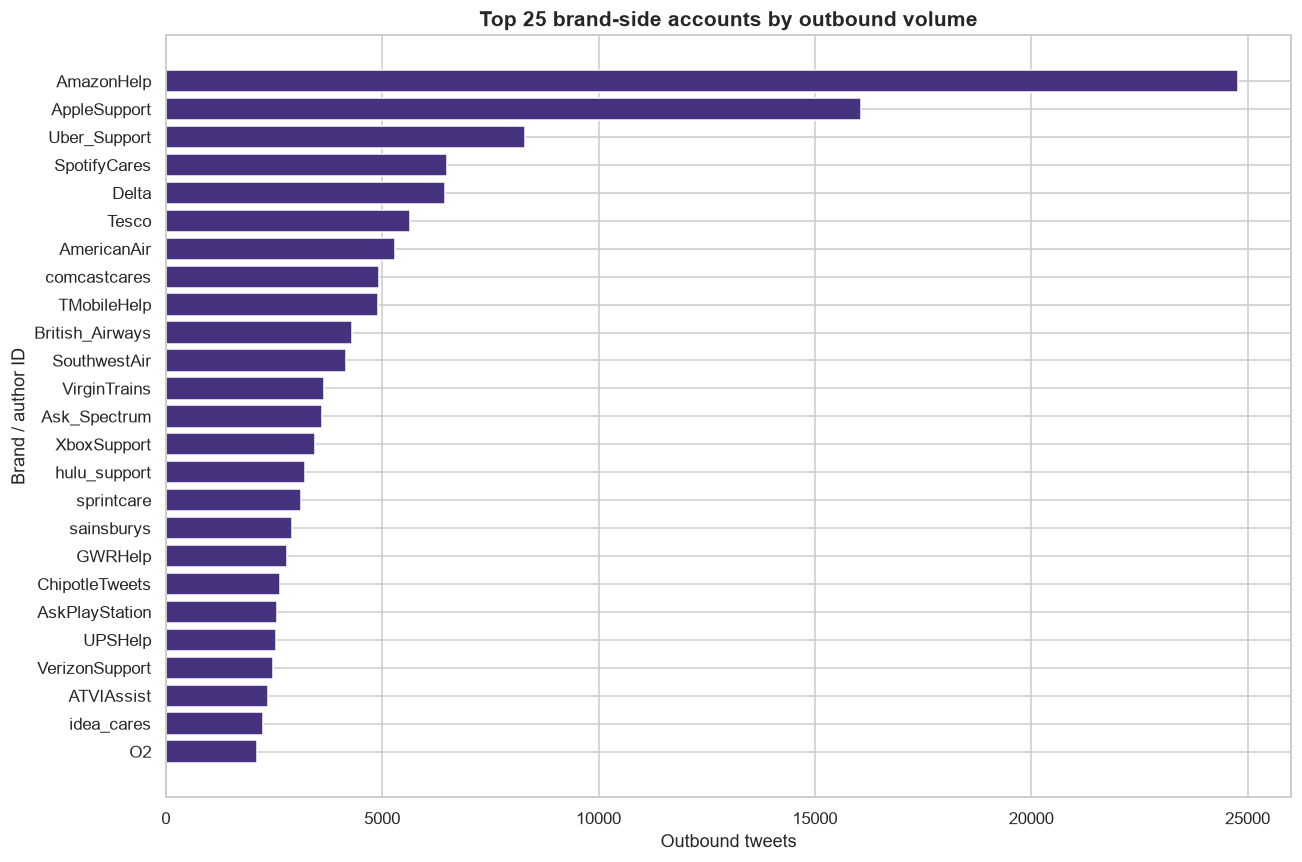

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\brand_summary_outbound_volume.png


In [10]:
# Cell 10: Thread dataframe construction + brand-level summary
#
# thread_df is built here (not in Cell 11) so that downstream cells
# can safely rely on it. Cell 11 verifies it without rebuilding.

thread_df = df.copy()

thread_df["inbound"] = normalize_inbound(thread_df["inbound"])

thread_df["tweet_id"] = pd.to_numeric(
    thread_df["tweet_id"],
    errors="raise",
).astype("int64")

thread_df["root_id"] = pd.to_numeric(
    thread_df["root_id"],
    errors="raise",
).astype("int64")

thread_df["created_at"] = pd.to_datetime(
    thread_df["created_at"],
    errors="coerce",
    utc=True,
)

thread_df = (
    thread_df
    .sort_values(
        ["root_id", "created_at", "tweet_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

# --------------------------------------------------------------
# Brand summary: outbound volume, thread count, unique customers
# --------------------------------------------------------------

brand_outbound_counts = (
    thread_df.loc[~thread_df["inbound"], "author_id"]
    .value_counts()
)

brand_summary = pd.DataFrame({
    "outbound_tweets": brand_outbound_counts,
})

brand_thread_counts = (
    thread_df.loc[~thread_df["inbound"]]
    .groupby("author_id")["root_id"]
    .nunique()
    .rename("n_threads")
)

brand_summary = brand_summary.join(
    brand_thread_counts,
    how="left",
)

brand_customer_counts = (
    thread_df.loc[~thread_df["inbound"]]
    .merge(
        thread_df.loc[
            thread_df["inbound"],
            ["root_id", "author_id"],
        ].rename(
            columns={"author_id": "customer_author_id"}
        ),
        on="root_id",
        how="left",
    )
    .groupby("author_id")["customer_author_id"]
    .nunique()
    .rename("unique_customers")
)

brand_summary = brand_summary.join(
    brand_customer_counts,
    how="left",
)

brand_summary = (
    brand_summary
    .fillna(0)
    .sort_values("outbound_tweets", ascending=False)
)

print(f"Unique brand-side authors: {len(brand_summary):,}")

print("\nTop 25 brands by outbound volume:")
display(brand_summary.head(25))

fig, ax = plt.subplots(figsize=(12, 8))

top_brands_volume = (
    brand_summary
    .head(25)["outbound_tweets"]
    .sort_values()
)

ax.barh(
    top_brands_volume.index.astype(str),
    top_brands_volume.values,
)

ax.set_title(
    "Top 25 brand-side accounts by outbound volume",
    fontsize=14,
    weight="bold",
)

ax.set_xlabel("Outbound tweets")
ax.set_ylabel("Brand / author ID")

plt.tight_layout()
plt.show()

save_fig(fig, "brand_summary_outbound_volume")

In [11]:
# Cell 11: Canonical thread reconstruction

required_cols = {
    "tweet_id",
    "root_id",
    "inbound",
    "text",
    "created_at",
    "in_response_to_tweet_id",
}

missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(
        f"Missing required columns: {sorted(missing_cols)}"
    )

thread_df = df.copy()

thread_df["inbound"] = normalize_inbound(thread_df["inbound"])
thread_df["tweet_id"] = pd.to_numeric(
    thread_df["tweet_id"],
    errors="raise",
).astype("int64")

thread_df["root_id"] = pd.to_numeric(
    thread_df["root_id"],
    errors="raise",
).astype("int64")

thread_df["created_at"] = pd.to_datetime(
    thread_df["created_at"],
    errors="coerce",
    utc=True,
)

thread_df = thread_df.sort_values(
    ["root_id", "created_at", "tweet_id"],
    kind="stable",
).reset_index(drop=True)

print(f"Tweets in sample: {len(thread_df):,}")
print(f"Unique threads:   {thread_df['root_id'].nunique():,}")
print(f"Inbound tweets:   {thread_df['inbound'].sum():,}")
print(f"Outbound tweets:  {(~thread_df['inbound']).sum():,}")

display(
    thread_df[
        [
            "tweet_id",
            "author_id",
            "inbound",
            "root_id",
            "created_at",
            "text",
        ]
    ].head(10)
)


Tweets in sample: 405,766
Unique threads:   118,101
Inbound tweets:   221,790
Outbound tweets:  183,976


,tweet_id,author_id,inbound,root_id,created_at,text
0,8,115712,True,8,2017-10-31 21:45:10+00:00,@sprintcare is the worst customer service
1,10,sprintcare,False,8,2017-10-31 21:45:59+00:00,@115712 Hello! We never like our customers to feel like they are not valued.
2,9,sprintcare,False,8,2017-10-31 21:46:14+00:00,@115712 I would love the chance to review the account and provide assistance.
3,6,sprintcare,False,8,2017-10-31 21:46:24+00:00,"@115712 Can you please send us a private message, so that I can gain further details about your account?"
4,7,115712,True,8,2017-10-31 21:47:48+00:00,@sprintcare the only way I can get a response is to tweet apparently
5,5,115712,True,8,2017-10-31 21:49:35+00:00,@sprintcare I did.
6,4,sprintcare,False,8,2017-10-31 21:54:49+00:00,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your ...
7,3,115712,True,8,2017-10-31 22:08:27+00:00,@sprintcare I have sent several private messages and no one is responding as usual
8,1,sprintcare,False,8,2017-10-31 22:10:47+00:00,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further as...
9,2,115712,True,8,2017-10-31 22:11:45+00:00,@sprintcare and how do you propose we do that


In [12]:
# Cell 12: Thread integrity validation

print("=" * 72)
print("THREAD INTEGRITY")
print("=" * 72)

tweet_ids = set(
    thread_df["tweet_id"].astype("int64")
)

parent_refs = pd.to_numeric(
    thread_df["in_response_to_tweet_id"],
    errors="coerce",
).dropna().astype("int64")

missing_parent_count = (
    ~parent_refs.isin(tweet_ids)
).sum()

missing_parent_rate = (
    missing_parent_count / max(len(parent_refs), 1)
)

print(
    f"Tweets with parent references:          {len(parent_refs):,}"
)
print(
    f"Parent references missing:              {missing_parent_count:,}"
)
print(
    f"Missing-parent rate:                    {missing_parent_rate:.2%}"
)

parent_rows = thread_df[
    thread_df["in_response_to_tweet_id"].notna()
].copy()

parent_rows["parent_id"] = pd.to_numeric(
    parent_rows["in_response_to_tweet_id"],
    errors="coerce",
).astype("Int64")

parent_lookup = thread_df[
    ["tweet_id", "root_id"]
].rename(
    columns={
        "tweet_id": "parent_id",
        "root_id": "parent_root_id",
    }
)

parent_check = parent_rows.merge(
    parent_lookup,
    on="parent_id",
    how="left",
)

parent_exists = parent_check["parent_root_id"].notna()

cross_root_count = (
    parent_exists
    & (
        parent_check["root_id"]
        != parent_check["parent_root_id"]
    )
).sum()

print(
    f"Parent exists in sample:               {parent_exists.sum():,}"
)
print(
    f"Cross-root parent violations:           {cross_root_count:,}"
)
print(
    f"Missing parent rows:                    "
    f"{(~parent_exists).sum():,}"
)

inbound_tweet_ids = set(
    thread_df.loc[
        thread_df["inbound"],
        "tweet_id",
    ].astype("int64")
)

root_ids = set(
    thread_df["root_id"].astype("int64")
)

invalid_roots = root_ids - inbound_tweet_ids

print(
    f"Unique roots:                           {len(root_ids):,}"
)
print(
    f"Roots not represented by inbound tweets: {len(invalid_roots):,}"
)

# Thread lengths.
thread_lengths = (
    thread_df
    .groupby("root_id")
    .size()
    .sort_values()
)

bucket_df = pd.DataFrame({
    "threads": {
        "singleton (1)": int((thread_lengths == 1).sum()),
        "2 tweets": int((thread_lengths == 2).sum()),
        "3 tweets": int((thread_lengths == 3).sum()),
        "4 tweets": int((thread_lengths == 4).sum()),
        "5+ tweets": int((thread_lengths >= 5).sum()),
    }
})

bucket_df["pct"] = (
    bucket_df["threads"]
    / len(thread_lengths)
    * 100
).round(2)

print("\nThread-length distribution:")
display(bucket_df)

print("\nDescriptive statistics:")
display(thread_lengths.describe())

print(
    f"\nThreads >= 3 tweets: "
    f"{(thread_lengths >= 3).mean():.2%}"
)

if missing_parent_rate > 0.005:
    print("WARNING: missing-parent rate is higher than 0.5%.")

if cross_root_count > 0:
    print("WARNING: cross-root parent violations detected.")

if invalid_roots:
    print("WARNING: invalid roots detected.")


THREAD INTEGRITY
Tweets with parent references:          287,665
Parent references missing:              0
Missing-parent rate:                    0.00%
Parent exists in sample:               287,665
Cross-root parent violations:           0
Missing parent rows:                    0
Unique roots:                           118,101
Roots not represented by inbound tweets: 0

Thread-length distribution:


,threads,pct
singleton (1),0,0.00
2 tweets,65162,55.17
3 tweets,16071,13.61
4 tweets,15564,13.18
5+ tweets,21304,18.04



Descriptive statistics:


count    118101.000000
mean          3.435754
std           3.418907
min           2.000000
25%           2.000000
50%           2.000000
75%           4.000000
max         385.000000
dtype: float64


Threads >= 3 tweets: 44.83%


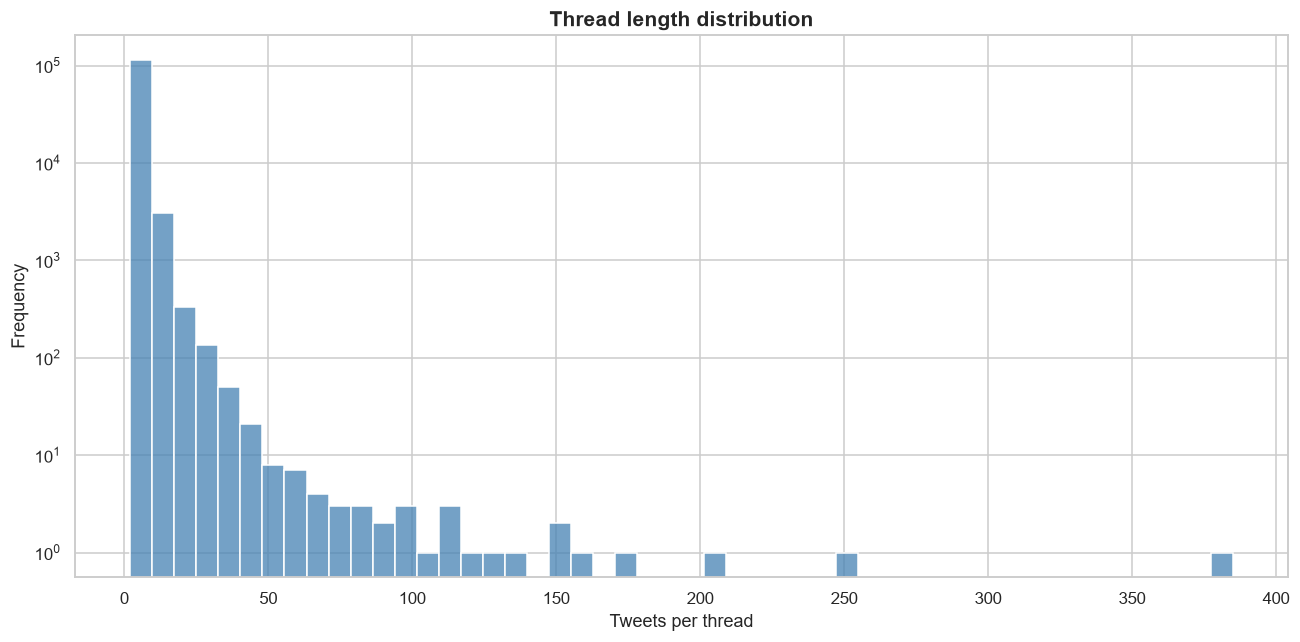

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\thread_length_distribution.png
Mean thread length:   3.44
Median thread length: 2
Threads >= 2 tweets: 100.00%
Threads >= 3 tweets: 44.83%
Threads >= 5 tweets: 18.04%
Max thread length:    385


In [13]:
# Cell 13: Thread length distribution

fig = show_hist(
    thread_lengths,
    "Thread length distribution",
    "Tweets per thread",
    bins=50,
    log_y=True,
)
save_fig(fig, "thread_length_distribution")

print(
    f"Mean thread length:   {thread_lengths.mean():.2f}"
)
print(
    f"Median thread length: {thread_lengths.median():.0f}"
)
print(
    f"Threads >= 2 tweets: "
    f"{(thread_lengths >= 2).mean():.2%}"
)
print(
    f"Threads >= 3 tweets: "
    f"{(thread_lengths >= 3).mean():.2%}"
)
print(
    f"Threads >= 5 tweets: "
    f"{(thread_lengths >= 5).mean():.2%}"
)
print(
    f"Max thread length:    {thread_lengths.max():,}"
)


In [14]:
# Cell 14: Canonical conversation unit + thread-level statistics
#
# This is the ONLY builder for first_inbound_per_thread.
# Ordering is chronological, not tweet_id order.
# .head(1) is used instead of .first() so that the actual earliest row
# is selected, not per-column first non-null values.

thread_stats = (
    thread_df
    .groupby("root_id")
    .agg(
        n_tweets=("tweet_id", "size"),
        n_inbound=("inbound", "sum"),
        n_outbound=("inbound", lambda s: int((~s).sum())),
    )
    .reset_index()
)

# First inbound customer message per thread.
first_inbound = (
    thread_df.loc[thread_df["inbound"]]
    .sort_values(
        ["root_id", "created_at", "tweet_id"],
        kind="stable",
    )
    .groupby("root_id")
    .head(1)
    .rename(
        columns={
            "tweet_id": "first_inbound_tweet_id",
            "author_id": "customer_author_id",
            "text": "customer_text",
        }
    )[
        [
            "root_id",
            "first_inbound_tweet_id",
            "customer_author_id",
            "customer_text",
            "created_at",
        ]
    ]
    .reset_index(drop=True)
)

# First brand-side response per thread.
first_brand = (
    thread_df.loc[~thread_df["inbound"]]
    .sort_values(
        ["root_id", "created_at", "tweet_id"],
        kind="stable",
    )
    .groupby("root_id")
    .head(1)
    [["root_id", "author_id"]]
    .rename(columns={"author_id": "brand_author_id"})
    .reset_index(drop=True)
)

first_inbound = (
    first_inbound
    .merge(thread_stats, on="root_id", how="left")
    .merge(first_brand, on="root_id", how="left")
)

print(f"first_inbound_per_thread rows: {len(first_inbound):,}")
print(
    f"Threads with brand attached: "
    f"{first_inbound['brand_author_id'].notna().sum():,}"
)
print(
    f"Threads without brand attached: "
    f"{first_inbound['brand_author_id'].isna().sum():,}"
)

display(first_inbound.head(10))

first_inbound_per_thread rows: 118,101
Threads with brand attached: 118,101
Threads without brand attached: 0


,root_id,first_inbound_tweet_id,customer_author_id,customer_text,created_at,n_tweets,n_inbound,n_outbound,brand_author_id
0,8,8,115712,@sprintcare is the worst customer service,2017-10-31 21:45:10+00:00,10,5,5,sprintcare
1,20,20,115715,"@115714 whenever I contact customer support, they tell me I have shortcode enabled on my account, but I have never i...",2017-10-31 22:03:34+00:00,2,1,1,sprintcare
2,61,61,115724,.@VerizonSupport @115725 @115726 &gt;All of VERIZON IS DOWN&lt;\nWhe...,2017-10-31 22:00:36+00:00,2,1,1,VerizonSupport
3,69,69,115729,@ChipotleTweets messed up today and didn’t give me my $3 burrito although I was dressed up 😭,2017-10-31 22:03:32+00:00,2,1,1,ChipotleTweets
4,71,71,115730,hey @ChipotleTweets wanna come to Mammoth. I'll at least eat there once a week i promise,2017-10-31 22:03:06+00:00,2,1,1,ChipotleTweets
5,159,159,115736,"Btw @ChipotleTweets giving out $3 burritos if you dress up for Halloween 🎃 Call your Chipotle to make sure, they’re ...",2017-10-31 22:00:10+00:00,2,1,1,ChipotleTweets
6,202,202,115750,Excellent Halloweening @marksandspencer 👌🏼 #countcolin #halloween #food https://t.co/lq1cSooHdj,2017-10-31 20:20:57+00:00,2,1,1,marksandspencer
7,208,208,115752,@MicrosoftHelps I need assistance recovering 2 hotmail accounts. I have filled the recovery forms but am told am no...,2017-10-31 20:28:11+00:00,2,1,1,MicrosoftHelps
8,220,220,115759,@115758 Why was there a half gig update for world at war?,2017-10-31 19:15:05+00:00,2,1,1,ATVIAssist
9,250,250,115767,Any help here @AdobeCare? https://t.co/x50e57UG4E,2017-10-31 20:49:12+00:00,12,7,5,AdobeCare


In [15]:
# Cell 15: Historical response classification
#
# EDA-level heuristic, NOT ground truth.
# Hierarchy:
#   resolution > link_handoff > handoff_dm > info_request >
#   investigation > empathy_only > informational > other
#
# `informational` requires positive informational content.
# `other` is the fallback and is NOT substantive.

import re

URL_RE = re.compile(r"https?://\S+|www\.\S+", re.I)
LEADING_MENTIONS_RE = re.compile(r"^(\s*@\w+\s*)+")

HANDOFF_DM_PATTERNS = [
    r"\bdm us\b",
    r"\bdirect message\b",
    r"\bsend us a dm\b",
    r"\bprivate message\b",
    r"\bplease dm\b",
    r"\bmessage us\b",
    r"\bsend us a message\b",
]

LINK_DIRECTIVE_PATTERNS = [
    r"\bcheck\b",
    r"\bcontact\b",
    r"\breach\b",
    r"\bvisit\b",
    r"\bfollow\b",
    r"\bclick\b",
    r"\bgo to\b",
    r"\bsee\b",
    r"\bhere\b",
]

INFO_REQUEST_PATTERNS = [
    r"\border id\b",
    r"\border number\b",
    r"\btracking number\b",
    r"\bemail address\b",
    r"\baccount number\b",
    r"\bshare your order\b",
    r"\bprovide your order\b",
    r"\bshare the details\b",
    r"\bprovide the details\b",
    r"\bplease (share|provide|send)\b",
]

INVESTIGATION_PATTERNS = [
    r"\bwe'?d like to (investigate|look into|check)\b",
    r"\bwe (will|can) (investigate|look into|check)\b",
    r"\bwe'?ll (look into|check|investigate)\b",
]

RESOLUTION_PATTERNS = [
    r"\bhas been (processed|shipped|refunded|delivered|cancelled)\b",
    r"\bwas (processed|shipped|refunded|delivered|cancelled)\b",
    r"\bwe('ve| have) (refunded|shipped|processed|cancelled)\b",
    r"\bissued a refund\b",
    r"\brefund (has been|was) processed\b",
    r"\bwe fixed\b",
    r"\bthe issue is resolved\b",
]

EMPATHY_PATTERNS = [
    r"^\s*i'?m sorry\b",
    r"^\s*sorry to hear\b",
    r"^\s*apologies\b",
    r"^\s*we understand\b",
    r"^\s*we'?re sorry\b",
]

# Positive informational markers.
# `informational` now requires at least one of these.
INFORMATIONAL_PATTERNS = [
    r"\bplease try\b",
    r"\bthe reason (is|for)\b",
    r"\bthis (happens|occurs|is because)\b",
    r"\bhere'?s how\b",
    r"\bto (do|fix|resolve) (this|that|it)\b",
    r"\bmake sure\b",
    r"\byou (can|may|should) (try|check|use|do|reset|restart|update|reinstall|verify|confirm)\b",
    r"\bplease (note|remember|ensure|check|verify)\b",
    r"\bwe (recommend|suggest|advise)\b",
    r"\byour (order|account|package|delivery) (is|has|will|should)\b",
    r"\bcheck (your|the)\b",
    r"\btry (again|to|the)\b",
]


def strip_urls(text: str) -> str:
    text = URL_RE.sub(" ", str(text))
    return re.sub(r"\s+", " ", text).strip()


def strip_leading_mentions(text: str) -> str:
    return LEADING_MENTIONS_RE.sub("", text).strip()


def has_pattern(text: str, patterns: list[str]) -> bool:
    return any(re.search(p, text) for p in patterns)


def classify_response(text: str) -> str:
    raw = str(text).strip()
    t = raw.lower()
    no_url = strip_urls(t)
    no_url_no_mentions = strip_leading_mentions(no_url)

    has_url = bool(URL_RE.search(raw))
    has_link_directive = has_pattern(no_url, LINK_DIRECTIVE_PATTERNS)

    if has_pattern(t, RESOLUTION_PATTERNS):
        return "resolution"

    if has_url and has_link_directive:
        return "link_handoff"

    if has_pattern(t, HANDOFF_DM_PATTERNS):
        return "handoff_dm"

    if has_pattern(t, INFO_REQUEST_PATTERNS):
        return "info_request"

    if has_pattern(t, INVESTIGATION_PATTERNS):
        return "investigation"

    empathy_hit = has_pattern(no_url_no_mentions, EMPATHY_PATTERNS)
    info_hit = has_pattern(no_url_no_mentions, INFORMATIONAL_PATTERNS)

    # Empathy-only requires that there is NO informational content.
    if empathy_hit and not info_hit:
        return "empathy_only"

    if info_hit:
        return "informational"

    return "other"


brand_responses = thread_df.loc[~thread_df["inbound"]].copy()
brand_responses["case_type"] = brand_responses["text"].apply(classify_response)

case_type_dist = brand_responses["case_type"].value_counts()

print("Brand response case-type distribution:")
display(
    case_type_dist.to_frame("count").assign(
        pct=lambda d: (d["count"] / d["count"].sum() * 100).round(2)
    )
)

top_brands = brand_summary.head(15).index.tolist()

per_brand_case = (
    brand_responses[brand_responses["author_id"].isin(top_brands)]
    .groupby(["author_id", "case_type"])
    .size()
    .unstack(fill_value=0)
)

per_brand_case["total"] = per_brand_case.sum(axis=1)

for col in [
    "resolution",
    "link_handoff",
    "handoff_dm",
    "info_request",
    "investigation",
    "empathy_only",
    "informational",
    "other",
]:
    if col not in per_brand_case.columns:
        per_brand_case[col] = 0

SUBSTANTIVE_TYPES = {"investigation", "resolution", "informational"}

per_brand_case["substantive_count"] = (
    per_brand_case[list(SUBSTANTIVE_TYPES)].sum(axis=1)
)
per_brand_case["substantive_pct"] = (
    per_brand_case["substantive_count"] / per_brand_case["total"] * 100
).round(2)

per_brand_case = per_brand_case.sort_values("total", ascending=False)

display(per_brand_case.head(15))

brand_responses[
    ["tweet_id", "author_id", "text", "case_type"]
].to_csv(
    RUNS_DIR / "brand_responses_classified.csv",
    index=False,
)

Brand response case-type distribution:


,count,pct
case_type,,
other,108097,58.76
link_handoff,30758,16.72
handoff_dm,26068,14.17
informational,6085,3.31
info_request,5880,3.20
empathy_only,5585,3.04
investigation,1181,0.64
resolution,322,0.18


case_type,empathy_only,handoff_dm,info_request,informational,investigation,link_handoff,other,resolution,total,substantive_count,substantive_pct
author_id,,,,,,,,,,,
AmazonHelp,1662,26,779,616,295,7240,14072,85,24775,996,4.02
AppleSupport,36,3697,28,501,191,5343,6262,7,16065,699,4.35
Uber_Support,128,2150,343,314,17,3592,1746,3,8293,334,4.03
SpotifyCares,87,790,72,209,57,1732,3558,0,6505,266,4.09
Delta,121,410,176,113,5,398,5232,3,6458,121,1.87
Tesco,85,624,283,174,26,91,4349,6,5638,206,3.65
AmericanAir,298,405,123,176,47,245,3983,12,5289,235,4.44
comcastcares,54,1673,802,66,7,56,2264,2,4924,75,1.52
TMobileHelp,3,1568,105,167,35,1001,2032,0,4911,202,4.11


,n_threads,avg_thread_len,median_thread_len,deep_turn_rate,substantive_response_rate,score
brand,,,,,,
AmazonHelp,12250,4.436571,3.0,0.612653,0.040202,0.634391
VerizonSupport,1182,5.088832,4.0,0.646362,0.035815,0.457316
Tesco,2459,4.199268,4.0,0.689305,0.036538,0.440901
AskPlayStation,1783,3.314077,2.0,0.434661,0.188591,0.436930
GWRHelp,1612,4.091811,3.0,0.636476,0.053686,0.405805
XboxSupport,2010,3.917910,3.0,0.617413,0.062791,0.402436
VirginTrains,2062,4.185742,3.0,0.612997,0.022119,0.353068
idea_cares,1119,4.409294,3.0,0.616622,0.021295,0.352087
AppleSupport,12180,2.947126,2.0,0.349261,0.043511,0.328903


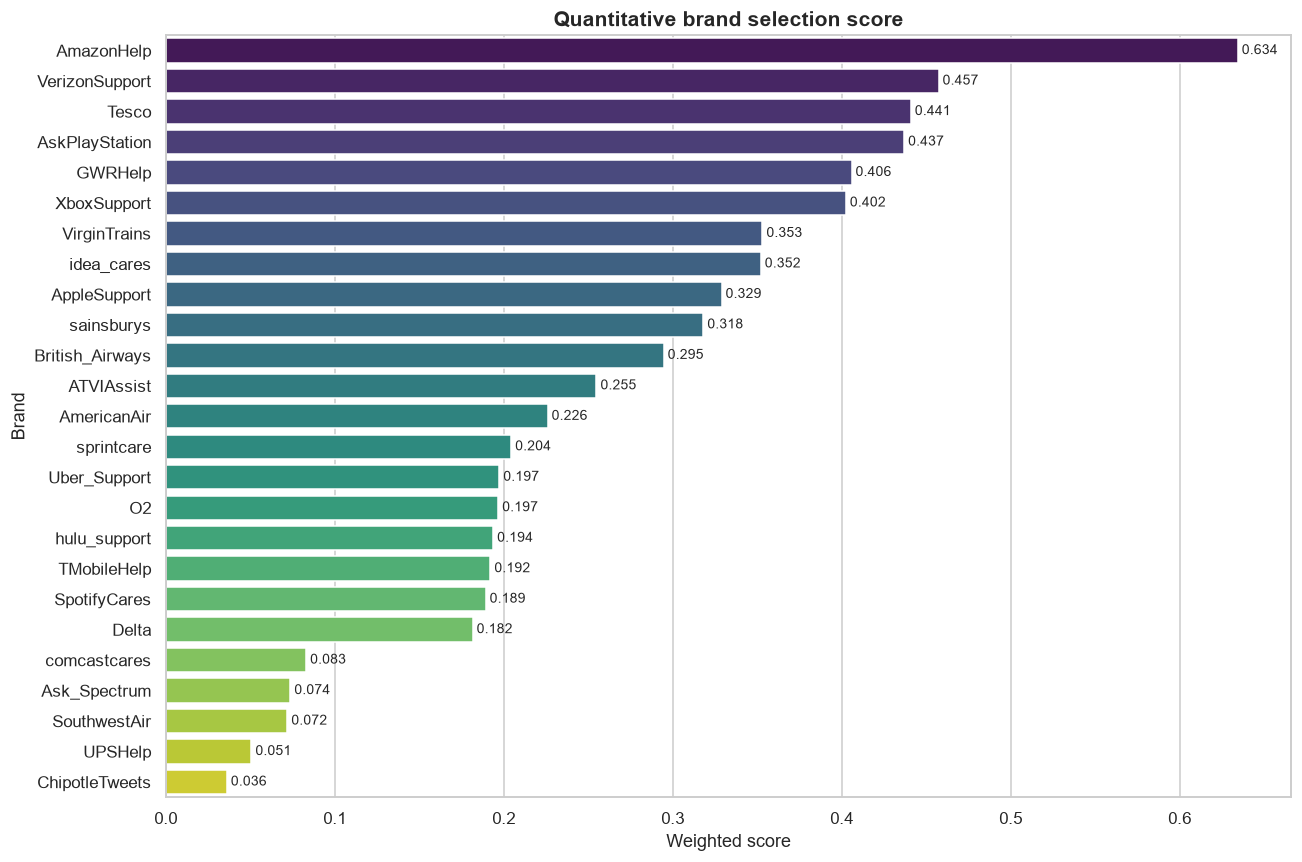

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\brand_selection_score.png

Brand comparison: volume, depth, resolution, handoff, substantive mix


,brand,n_threads,avg_len,deep_turn_pct,resolution_pct,handoff_pct,info_request_pct,empathy_only_pct,substantive_pct,other_pct
0,AmazonHelp,12250,4.44,61.27,0.34,29.33,3.14,6.71,4.02,56.80
1,AppleSupport,12180,2.95,34.93,0.04,56.27,0.17,0.22,4.35,38.98
2,Uber_Support,6250,3.01,35.20,0.04,69.24,4.14,1.54,4.03,21.05
3,AmericanAir,3837,3.30,42.51,0.23,12.29,2.33,5.63,4.44,75.31
4,Tesco,2459,4.20,68.93,0.11,12.68,5.02,1.51,3.65,77.14
5,British_Airways,2458,3.62,53.17,0.37,15.15,2.07,7.69,4.39,70.70
6,VirginTrains,2062,4.19,61.30,0.16,8.14,0.30,7.13,2.21,82.22
7,XboxSupport,2010,3.92,61.74,0.03,33.37,0.93,1.16,6.28,58.26
8,sprintcare,1901,3.66,46.03,0.00,45.98,1.92,1.12,2.53,48.45
9,AskPlayStation,1783,3.31,43.47,0.12,33.60,4.00,2.25,18.86,41.29


In [16]:
# Cell 16: Quantitative brand selection score + comparison table
#
# SUBSTANTIVE_TYPES is defined in Cell 15.
# multi_turn_rate (>=2) is omitted because valid threads necessarily
# contain a root customer tweet + at least one brand response.
# avg_response_char_len is omitted because longer responses are not
# inherently better.

CANDIDATES = brand_summary.head(TOP_N_BRANDS).index.tolist()

brand_resp_lookup = (
    brand_responses
    .groupby("author_id")["case_type"]
    .apply(lambda s: s.isin(SUBSTANTIVE_TYPES).mean())
    .rename("substantive_response_rate")
)

rows = []

for brand in CANDIDATES:

    brand_thread_ids = set(
        first_inbound.loc[
            first_inbound["brand_author_id"].eq(brand),
            "root_id",
        ].astype("int64")
    )

    if not brand_thread_ids:
        continue

    sub_threads = thread_stats[
        thread_stats["root_id"].isin(brand_thread_ids)
    ]

    if sub_threads.empty:
        continue

    rows.append({
        "brand": brand,
        "n_threads": int(len(sub_threads)),
        "avg_thread_len": float(sub_threads["n_tweets"].mean()),
        "median_thread_len": float(sub_threads["n_tweets"].median()),
        "deep_turn_rate": float((sub_threads["n_tweets"] >= 3).mean()),
        "substantive_response_rate": float(
            brand_resp_lookup.get(brand, np.nan)
        ),
    })

brand_scores = pd.DataFrame(rows).set_index("brand")


def norm(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    return (series - series.min()) / (series.max() - series.min() + 1e-9)


weights = {
    "n_threads": 0.25,
    "avg_thread_len": 0.20,
    "deep_turn_rate": 0.25,
    "substantive_response_rate": 0.30,
}

brand_scores["score"] = sum(
    norm(brand_scores[column]) * weight
    for column, weight in weights.items()
)

brand_scores = brand_scores.sort_values("score", ascending=False)

display(brand_scores)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    x=brand_scores["score"].values,
    y=brand_scores.index.astype(str),
    palette="viridis",
    ax=ax,
)

ax.set_title(
    "Quantitative brand selection score",
    fontsize=14,
    weight="bold",
)

ax.set_xlabel("Weighted score")
ax.set_ylabel("Brand")

for i, value in enumerate(brand_scores["score"].values):
    ax.text(value, i, f" {value:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

save_fig(fig, "brand_selection_score")


# --------------------------------------------------------------
# Brand comparison table
# --------------------------------------------------------------
# Shows volume, depth, resolution, handoff, and substantive mix side by side.
# Useful to explain why a high-volume brand may not be a good auto-resolve
# target for the agent.

comparison_rows = []

for brand in brand_scores.head(15).index:

    brand_root_ids = set(
        first_inbound.loc[
            first_inbound["brand_author_id"] == brand,
            "root_id",
        ].astype("int64")
    )

    sub_threads = thread_stats[
        thread_stats["root_id"].isin(brand_root_ids)
    ]

    if sub_threads.empty:
        continue

    brand_case = (
        brand_responses[
            brand_responses["author_id"] == brand
        ]["case_type"]
    )

    total = len(brand_case)

    def pct_of(cats):
        return (
            brand_case.isin(cats).sum() / max(total, 1) * 100
        )

    comparison_rows.append({
        "brand": brand,
        "n_threads": len(sub_threads),
        "avg_len": round(sub_threads["n_tweets"].mean(), 2),
        "deep_turn_pct": round(
            (sub_threads["n_tweets"] >= 3).mean() * 100, 2
        ),
        "resolution_pct": round(
            pct_of({"resolution"}), 2
        ),
        "handoff_pct": round(
            pct_of({"handoff_dm", "link_handoff"}), 2
        ),
        "info_request_pct": round(
            pct_of({"info_request"}), 2
        ),
        "empathy_only_pct": round(
            pct_of({"empathy_only"}), 2
        ),
        "substantive_pct": round(
            pct_of(SUBSTANTIVE_TYPES), 2
        ),
        "other_pct": round(
            pct_of({"other"}), 2
        ),
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("n_threads", ascending=False)
    .reset_index(drop=True)
)

print("\nBrand comparison: volume, depth, resolution, handoff, substantive mix")
display(comparison_df)

comparison_df.to_csv(
    RUNS_DIR / "brand_comparison_table.csv",
    index=False,
)

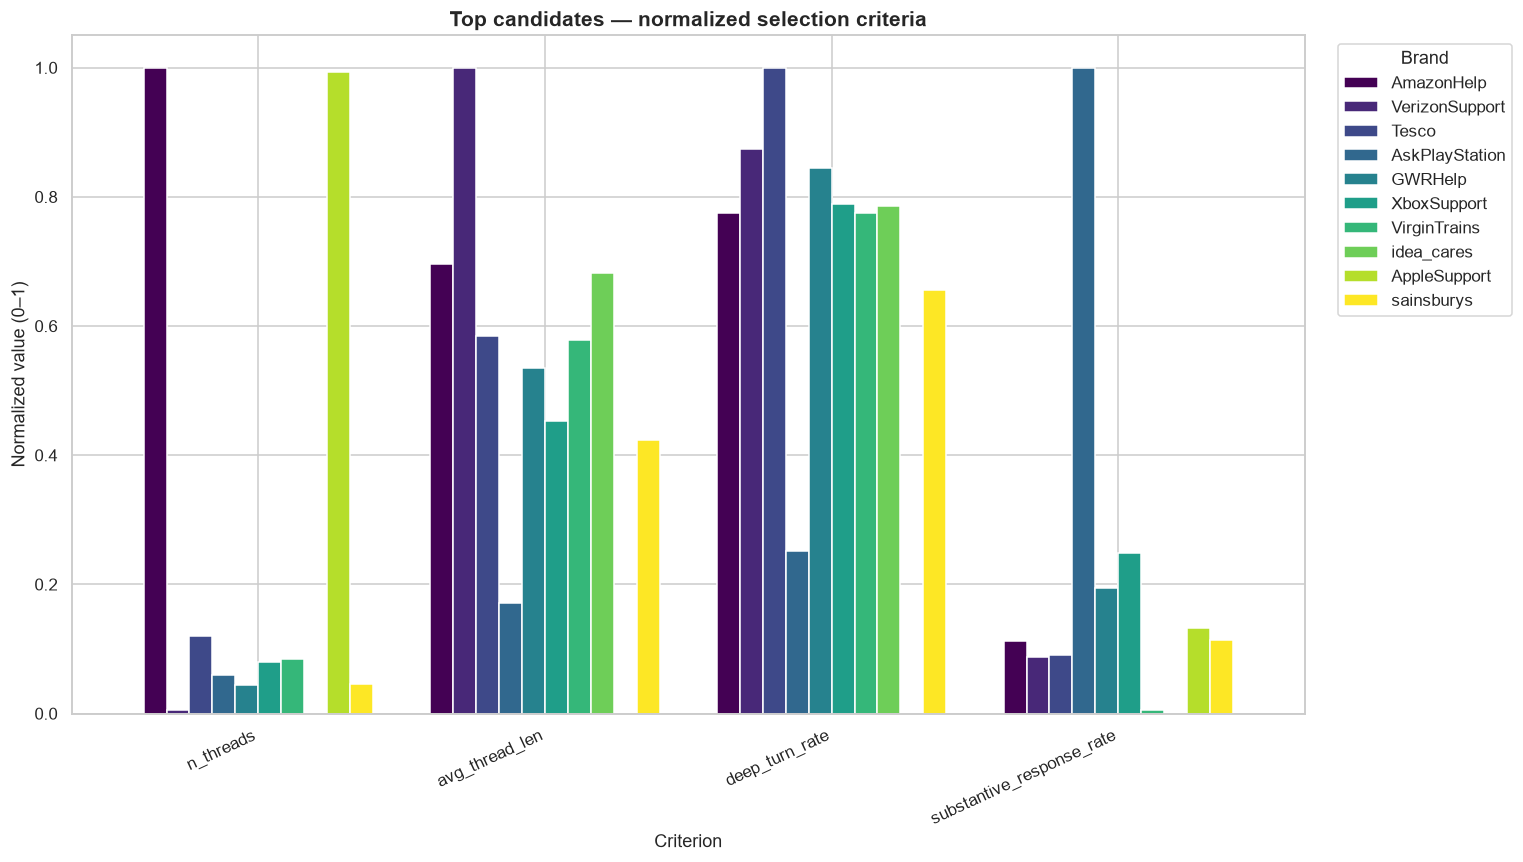

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\brand_criteria_comparison.png


In [17]:
# Cell 17: Compare top candidates on the actual score criteria

top_candidates = (
    brand_scores.head(10)
    .index
    .tolist()
)

criteria = [
    "n_threads",
    "avg_thread_len",
    "deep_turn_rate",
    "substantive_response_rate",
]

plot_df = brand_scores.loc[
    top_candidates,
    criteria,
].copy()

plot_df_norm = plot_df.apply(norm)

fig, ax = plt.subplots(
    figsize=(14, 8)
)

plot_df_norm.T.plot(
    kind="bar",
    ax=ax,
    colormap="viridis",
    width=0.8,
)

ax.set_title(
    "Top candidates — normalized selection criteria",
    fontsize=14,
    weight="bold",
)

ax.set_ylabel("Normalized value (0–1)")
ax.set_xlabel("Criterion")

plt.xticks(
    rotation=25,
    ha="right",
)

plt.legend(
    title="Brand",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

save_fig(
    fig,
    "brand_criteria_comparison",
)


In [31]:
# Cell 18: Provisional top candidate inspection
#
# This does NOT lock the brand.

PROVISIONAL_BRAND = brand_scores.index[0]

print(
    f"Quantitative top candidate: "
    f"{PROVISIONAL_BRAND}"
)

print(
    "Status: PROVISIONAL — "
    "manual candidate audit required."
)

brand_root_ids = set(
    first_inbound.loc[
        first_inbound["brand_author_id"]
        == PROVISIONAL_BRAND,
        "root_id",
    ].astype("int64")
)

brand_threads = thread_stats[
    thread_stats["root_id"].isin(
        brand_root_ids
    )
]

brand_tweets = thread_df[
    (thread_df["author_id"] == PROVISIONAL_BRAND)
    & (~thread_df["inbound"])
].copy()

print(
    f"\nThreads: {len(brand_threads):,}"
)
print(
    f"Brand tweets: {len(brand_tweets):,}"
)
print(
    f"Avg thread length: "
    f"{brand_threads['n_tweets'].mean():.2f}"
)
print(
    f"Deep-turn rate (>=3): "
    f"{(brand_threads['n_tweets'] >= 3).mean():.2%}"
)

brand_case = (
    brand_responses[
        brand_responses["author_id"]
        == PROVISIONAL_BRAND
    ]["case_type"]
    .value_counts()
)

print(
    f"\nCase-type breakdown for "
    f"{PROVISIONAL_BRAND}:"
)

display(
    brand_case.to_frame("count").assign(
        pct=lambda d: (
            d["count"]
            / d["count"].sum()
            * 100
        ).round(2)
    )
)

# Sample complete threads in chronological order.
print(
    "\nSample threads from provisional candidate:"
)

sample_count = min(
    5,
    len(brand_threads),
)

sample_thread_ids = (
    brand_threads
    .sample(
        sample_count,
        random_state=SAMPLE_SEED,
    )["root_id"]
    .tolist()
)

for root in sample_thread_ids:
    print("\n" + "=" * 90)

    thread = (
        thread_df[
            thread_df["root_id"] == root
        ]
        .sort_values(
            ["created_at", "tweet_id"],
            kind="stable",
        )
    )

    for _, row in thread.iterrows():
        who = (
            "CUSTOMER"
            if row["inbound"]
            else "BRAND"
        )

        print(
            f"[{who}] "
            f"{str(row['text'])[:400]}"
        )


Quantitative top candidate: AmazonHelp
Status: PROVISIONAL — manual candidate audit required.

Threads: 12,250
Brand tweets: 24,775
Avg thread length: 4.44
Deep-turn rate (>=3): 61.27%

Case-type breakdown for AmazonHelp:


,count,pct
case_type,,
other,14072,56.80
link_handoff,7240,29.22
empathy_only,1662,6.71
info_request,779,3.14
informational,616,2.49
investigation,295,1.19
resolution,85,0.34
handoff_dm,26,0.10



Sample threads from provisional candidate:

[CUSTOMER] Thank you @115821 for NOT helping with a seller, I will remember that when renewing my prime membership.
[BRAND] @587121 Hello Roni, can you explain with more details what happened without posting personal information? ^DA
[CUSTOMER] @AmazonHelp Bought a product for 289 it didn't work for me, then I got a refund of 231 + 40 of shipping back. So 100 dollars for nothing :(
[BRAND] @587121 Sorry for the inconvenient. Have you contacted Customer Support to report what you inform us? ^DA
[CUSTOMER] @AmazonHelp Of course
[BRAND] @587121 When you contacted us, what information was provided by Customer Service? ^AD
[CUSTOMER] @AmazonHelp 😴😴😴😴

[CUSTOMER] @115830 free delivery with prime is all well and good but do I really need such a large box for 1 CD?!!!! https://t.co/QEoSAuHyAR
[BRAND] @141414 Oh my! That is certainly a large box, Peter! We're always looking to improve, and we would love to get your feedback about our packaging! If yo

First-inbound messages for AmazonHelp: 12,250
count    12250.000000
mean       124.680327
std         55.726877
min          8.000000
25%         87.000000
50%        126.000000
75%        145.000000
max        315.000000
Name: customer_text, dtype: float64


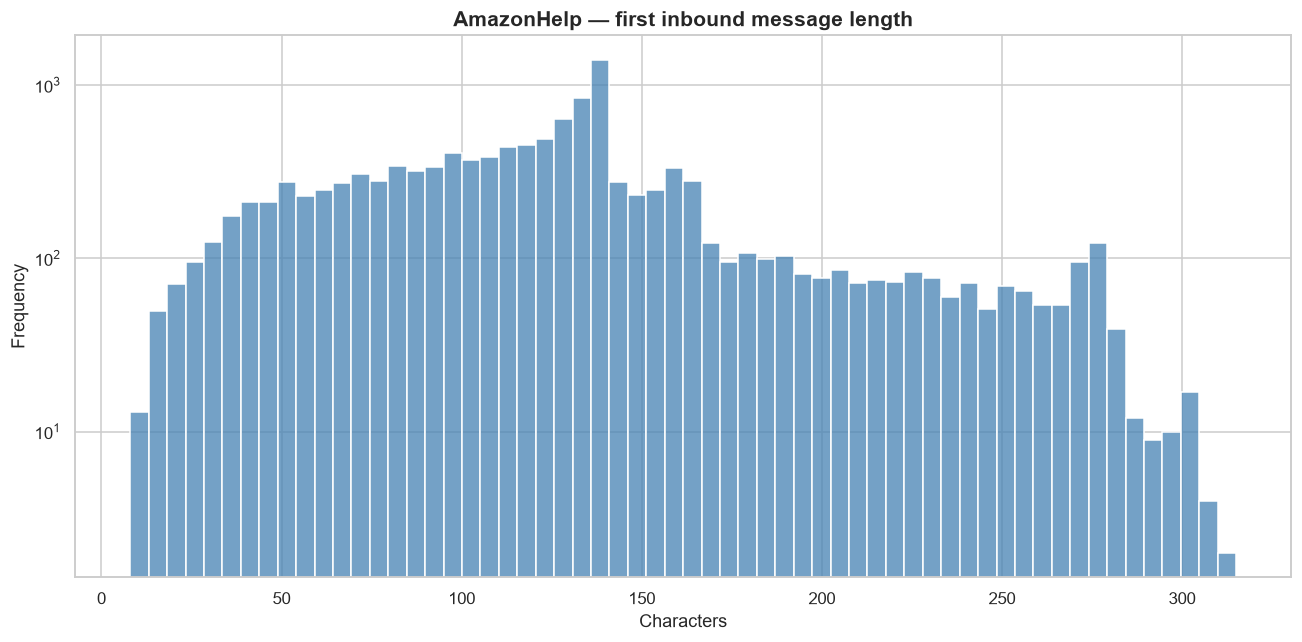

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\first_inbound_message_length.png


,matching_messages
support,3829
delivery,2537
account,494
refund,437
cancel,387
complaint,370
billing,350
damage,249


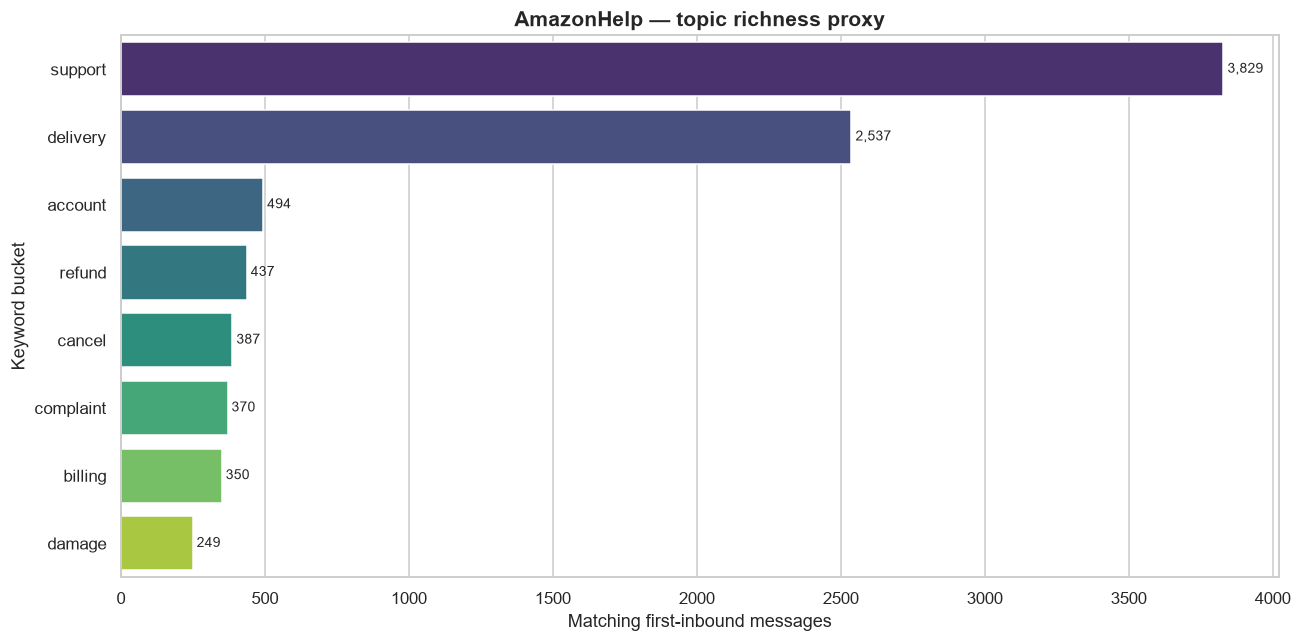

Saved: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\reports\figures\topic_richness_proxy.png


In [32]:
# Cell 19: Topic richness proxy
#
# Keyword buckets are only a sanity check.
# They are NOT the intent taxonomy.

brand_inbound = first_inbound[
    first_inbound["brand_author_id"]
    == PROVISIONAL_BRAND
].copy()

print(
    f"First-inbound messages for "
    f"{PROVISIONAL_BRAND}: "
    f"{len(brand_inbound):,}"
)

texts = (
    brand_inbound["customer_text"]
    .fillna("")
    .astype(str)
)

lengths = texts.str.len()

print(lengths.describe())

fig = show_hist(
    lengths,
    f"{PROVISIONAL_BRAND} — first inbound message length",
    "Characters",
    bins=60,
    log_y=True,
)

save_fig(
    fig,
    "first_inbound_message_length",
)

keywords = {
    "refund": [
        "refund",
        "money back",
        "reimburse",
    ],
    "delivery": [
        "delivery",
        "shipped",
        "arrive",
        "tracking",
        "package",
    ],
    "account": [
        "account",
        "login",
        "password",
        "sign in",
        "locked",
    ],
    "billing": [
        "charge",
        "billed",
        "payment",
        "invoice",
    ],
    "cancel": [
        "cancel",
        "subscription",
        "unsubscribe",
    ],
    "damage": [
        "damaged",
        "broken",
        "defective",
        "not working",
    ],
    "support": [
        "help",
        "support",
        "assist",
    ],
    "complaint": [
        "complaint",
        "terrible",
        "worst",
        "angry",
        "unacceptable",
    ],
}

lower_texts = texts.str.lower()

bucket_counts = {}

for bucket, words in keywords.items():
    mask = lower_texts.apply(
        lambda text: any(
            word in text
            for word in words
        )
    )

    bucket_counts[bucket] = int(mask.sum())

bucket_series = (
    pd.Series(bucket_counts)
    .sort_values(ascending=False)
)

display(
    bucket_series.to_frame("matching_messages")
)

fig = show_bar(
    bucket_series,
    f"{PROVISIONAL_BRAND} — topic richness proxy",
    "Matching first-inbound messages",
    "Keyword bucket",
    top_n=20,
)

save_fig(
    fig,
    "topic_richness_proxy",
)


In [33]:
# ============================================================
# Cell 20: Manual audit sample generation (dynamic)
# ============================================================

AUDIT_CANDIDATES = brand_scores.head(5).index.tolist()

print("Audit candidates:")
for i, brand in enumerate(AUDIT_CANDIDATES, 1):
    print(f"{i}. {brand}")

audit_base = first_inbound.copy()
audit_base = audit_base[
    audit_base["brand_author_id"].isin(AUDIT_CANDIDATES)
].copy()

def depth_bucket(n):
    if n == 2:
        return "two_tweet"
    elif 3 <= n <= 4:
        return "three_to_four_tweet"
    else:
        return "deep_multi_turn"

audit_base["sampling_bucket"] = audit_base["n_tweets"].apply(depth_bucket)

POOL_SIZE = 50
rng = np.random.default_rng(SAMPLE_SEED)

pool_rows = []
for brand in AUDIT_CANDIDATES:
    brand_df = audit_base[audit_base["brand_author_id"] == brand].copy()

    bucket_targets = {
        "two_tweet": 17,
        "three_to_four_tweet": 17,
        "deep_multi_turn": 16,
    }

    sampled_parts = []
    for bucket, n in bucket_targets.items():
        bucket_df = brand_df[brand_df["sampling_bucket"] == bucket]
        if len(bucket_df) == 0:
            continue
        n_take = min(n, len(bucket_df))
        sampled_parts.append(
            bucket_df.sample(n=n_take, random_state=SAMPLE_SEED)
        )

    sampled = pd.concat(sampled_parts, ignore_index=True)

    remaining = POOL_SIZE - len(sampled)
    if remaining > 0:
        already_selected = set(sampled["root_id"])
        remaining_df = brand_df[~brand_df["root_id"].isin(already_selected)]
        if len(remaining_df) > 0:
            backfill_n = min(remaining, len(remaining_df))
            sampled = pd.concat(
                [
                    sampled,
                    remaining_df.sample(n=backfill_n, random_state=SAMPLE_SEED),
                ],
                ignore_index=True,
            )

    sampled["audit_pool_rank"] = np.arange(1, len(sampled) + 1)
    pool_rows.append(sampled)

candidate_audit_samples = pd.concat(pool_rows, ignore_index=True)
candidate_audit_samples = candidate_audit_samples[
    [
        "brand_author_id",
        "root_id",
        "first_inbound_tweet_id",
        "customer_text",
        "n_tweets",
        "sampling_bucket",
        "audit_pool_rank",
    ]
].rename(columns={"brand_author_id": "brand"})

candidate_audit_samples = candidate_audit_samples.sort_values(
    ["brand", "sampling_bucket", "audit_pool_rank"]
).reset_index(drop=True)

print(f"Generated {len(candidate_audit_samples):,} audit-pool rows")
display(
    candidate_audit_samples
    .groupby(["brand", "sampling_bucket"])
    .size()
    .unstack(fill_value=0)
)

candidate_audit_samples.to_csv(
    RUNS_DIR / "candidate_audit_samples.csv", index=False
)
candidate_audit_samples.to_pickle(
    RUNS_DIR / "candidate_audit_samples.pkl"
)

Audit candidates:
1. AmazonHelp
2. VerizonSupport
3. Tesco
4. AskPlayStation
5. GWRHelp
Generated 250 audit-pool rows


sampling_bucket,deep_multi_turn,three_to_four_tweet,two_tweet
brand,,,
AmazonHelp,16,17,17
AskPlayStation,16,17,17
GWRHelp,16,17,17
Tesco,16,17,17
VerizonSupport,16,17,17


In [34]:
# ============================================================
# Cell 20b: Select 10 threads per brand for manual review
# ============================================================

MANUAL_PER_BRAND = 10

manual_rows = []
for brand in AUDIT_CANDIDATES:
    brand_pool = candidate_audit_samples[
        candidate_audit_samples["brand"] == brand
    ].copy()

    targets = {
        "two_tweet": 4,
        "three_to_four_tweet": 3,
        "deep_multi_turn": 3,
    }

    for bucket, n in targets.items():
        bucket_df = brand_pool[brand_pool["sampling_bucket"] == bucket]
        n_take = min(n, len(bucket_df))
        if n_take > 0:
            manual_rows.append(
                bucket_df.sample(n=n_take, random_state=SAMPLE_SEED)
            )

manual_audit_samples = pd.concat(manual_rows, ignore_index=True)
manual_audit_samples = manual_audit_samples.sort_values(
    ["brand", "sampling_bucket"]
).reset_index(drop=True)

print(f"Manual review set: {len(manual_audit_samples)} threads")
display(
    manual_audit_samples
    .groupby(["brand", "sampling_bucket"])
    .size()
    .unstack(fill_value=0)
)

manual_audit_samples.to_csv(
    RUNS_DIR / "manual_audit_samples.csv", index=False
)

Manual review set: 50 threads


sampling_bucket,deep_multi_turn,three_to_four_tweet,two_tweet
brand,,,
AmazonHelp,3,3,4
AskPlayStation,3,3,4
GWRHelp,3,3,4
Tesco,3,3,4
VerizonSupport,3,3,4


In [35]:
# ============================================================
# Cell 20c: show_thread helper for manual review
# ============================================================

def show_thread(root_id):
    thread = (
        thread_df[thread_df["root_id"] == root_id]
        .sort_values(["created_at", "tweet_id"], kind="stable")
    )
    print("=" * 100)
    print(f"ROOT ID: {root_id}")
    print("=" * 100)
    for _, row in thread.iterrows():
        who = "CUSTOMER" if row["inbound"] else "BRAND"
        print(f"\n[{who}]")
        print(row["text"])

In [36]:
# ============================================================
# Cell 21: Manual review — print 10 threads per brand
# ============================================================

for brand in AUDIT_CANDIDATES:
    print("\n" + "#" * 100)
    print(f"# {brand}")
    print("#" * 100)

    sample_ids = (
        manual_audit_samples[
            manual_audit_samples["brand"] == brand
        ]["root_id"].tolist()
    )

    for root_id in sample_ids:
        show_thread(root_id)


####################################################################################################
# AmazonHelp
####################################################################################################
ROOT ID: 987995

[CUSTOMER]
Today 14th.Product ordered on 23rd Sept neither quality delivered nor refund.No refund by 2morow will lodge policeComplaint&amp;approach C.court https://t.co/pCzM5cLt8Z

[CUSTOMER]
Online shopping in India is RamBhrose @115850 quality better but on average,but had similar bitter experience.Will @118342 look into

[CUSTOMER]
@115850 @118342 Formulate implementable laws 4 online portals&amp;shopping.In India dey get away,had it been u.s.dey'd be sued&amp;made to care @118342  Rgrds

[BRAND]
@354096 I'm sorry for the unpleasant experience with this order delivery. It is never our intention to cause inconvenience to our 1/2 ^MJ

[BRAND]
@354096 valued customer. Write to us here: https://t.co/GIJyeYqKE0 &amp; we'll help you with available options. 2/2

In [37]:
# ============================================================
# Cell 22a: Create empty audit template (run once)
# ============================================================

EVAL_DIR = PROJECT_ROOT / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

AUDIT_CRITERIA = [
    "issue_diversity_1_5",
    "response_usefulness_1_5",
    "resolution_evidence_1_5",
    "context_availability_1_5",
    "ambiguity_challenge_1_5",
    "behavioral_consistency_1_5",
    "data_cleanliness_1_5",
    "automation_suitability_1_5",
]

audit_template_path = EVAL_DIR / "candidate_audit.csv"

if not audit_template_path.exists():
    audit_template = pd.DataFrame({
        "brand": AUDIT_CANDIDATES,
        **{c: np.nan for c in AUDIT_CRITERIA},
        "notes": "",
    })
    audit_template.to_csv(audit_template_path, index=False)
    print(f"Template created: {audit_template_path}")
else:
    print(f"Template already exists: {audit_template_path}")

Template already exists: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\evaluation\candidate_audit.csv


In [42]:
AUDIT_PATH = PROJECT_ROOT / "evaluation" / "candidate_audit.csv"

print("Reading:", AUDIT_PATH)
print("Exists:", AUDIT_PATH.exists())

audit_scores = pd.read_csv(AUDIT_PATH)

print("\nColumns:")
print(audit_scores.columns.tolist())

print("\nData:")
display(audit_scores)

print("\nMissing values:")
display(audit_scores[AUDIT_CRITERIA].isna().sum())

print("\nDtypes:")
print(audit_scores[AUDIT_CRITERIA].dtypes)

Reading: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\evaluation\candidate_audit.csv
Exists: True

Columns:
['brand', 'issue_diversity_1_5', 'response_usefulness_1_5', 'resolution_evidence_1_5', 'context_availability_1_5', 'ambiguity_challenge_1_5', 'behavioral_consistency_1_5', 'data_cleanliness_1_5', 'automation_suitability_1_5', 'notes']

Data:


,brand,issue_diversity_1_5,response_usefulness_1_5,resolution_evidence_1_5,context_availability_1_5,ambiguity_challenge_1_5,behavioral_consistency_1_5,data_cleanliness_1_5,automation_suitability_1_5,notes
0,AmazonHelp,4,2,1,4,4,4,3,2,Volume leader; reply pattern dominated by link/DM handoffs; almost no visible resolutions; good ambiguity coverage b...
1,VerizonSupport,3,2,1,3,3,2,3,2,"Smaller sample; inconsistent reply quality (one snarky reply, several misrouted replies); generic handoffs dominate;..."
2,Tesco,4,4,3,4,3,4,5,4,"Best balance: clean English, consistent voice, several visible resolutions, good mix of FAQ-style and complaint-styl..."
3,AskPlayStation,3,3,2,3,4,3,3,2,Rich technical ambiguity; high context-dependence; account-specific and security issues; some customer-to-customer c...
4,GWRHelp,3,5,4,4,3,5,5,4,Small but very high quality; consistent professional style; frequent direct answers; several visible resolutions; cl...



Missing values:


issue_diversity_1_5           0
response_usefulness_1_5       0
resolution_evidence_1_5       0
context_availability_1_5      0
ambiguity_challenge_1_5       0
behavioral_consistency_1_5    0
data_cleanliness_1_5          0
automation_suitability_1_5    0
dtype: int64


Dtypes:
issue_diversity_1_5           int64
response_usefulness_1_5       int64
resolution_evidence_1_5       int64
context_availability_1_5      int64
ambiguity_challenge_1_5       int64
behavioral_consistency_1_5    int64
data_cleanliness_1_5          int64
automation_suitability_1_5    int64
dtype: object


In [49]:
# ============================================================
# Cell 22b: Combine quantitative + audit scores
# ============================================================

audit_scores = pd.read_csv(audit_template_path)

if audit_scores[AUDIT_CRITERIA].isna().any().any():
    print("Manual audit incomplete. Fill candidate_audit.csv first.")
else:
    audit_scores["audit_mean_1_5"] = audit_scores[AUDIT_CRITERIA].mean(axis=1)
    audit_scores["audit_score_0_1"] = (
        audit_scores["audit_mean_1_5"] - 1
    ) / 4

    comparison = (
        brand_scores[["score"]]
        .rename(columns={"score": "quant_score_0_1"})
        .reset_index()
        .rename(columns={"brand": "brand"})
        .merge(
            audit_scores[["brand", "audit_mean_1_5", "audit_score_0_1", "notes"]],
            on="brand",
            how="inner",
        )
    )

    comparison["final_score_0_1"] = (
        0.5 * comparison["quant_score_0_1"]
        + 0.5 * comparison["audit_score_0_1"]
    )

    comparison = comparison.sort_values(
        "final_score_0_1", ascending=False
    ).reset_index(drop=True)

    winner = comparison.iloc[0]
    runner_up = comparison.iloc[1]
    gap = winner["final_score_0_1"] - runner_up["final_score_0_1"]

    quant_winner = brand_scores.index[0]
    audit_winner = (
        comparison.sort_values("audit_mean_1_5", ascending=False)
        .iloc[0]["brand"]
    )

    print(f"Quantitative winner:   {quant_winner}")
    print(f"Audit winner:          {audit_winner}")
    print(f"Final-score winner:    {winner['brand']}")
    print(f"Final-score gap:       {gap:.3f}")

    display(comparison)

    comparison.to_csv(
        RUNS_DIR / "brand_final_comparison.csv", index=False
    )

Quantitative winner:   AmazonHelp
Audit winner:          GWRHelp
Final-score winner:    GWRHelp
Final-score gap:       0.014


,brand,quant_score_0_1,audit_mean_1_5,audit_score_0_1,notes,final_score_0_1
0,GWRHelp,0.405805,4.125,0.78125,Small but very high quality; consistent professional style; frequent direct answers; several visible resolutions; cl...,0.593528
1,Tesco,0.440901,3.875,0.71875,"Best balance: clean English, consistent voice, several visible resolutions, good mix of FAQ-style and complaint-styl...",0.579826
2,AmazonHelp,0.634391,3.000,0.50000,Volume leader; reply pattern dominated by link/DM handoffs; almost no visible resolutions; good ambiguity coverage b...,0.567195
3,AskPlayStation,0.436930,2.875,0.46875,Rich technical ambiguity; high context-dependence; account-specific and security issues; some customer-to-customer c...,0.452840
4,VerizonSupport,0.457316,2.375,0.34375,"Smaller sample; inconsistent reply quality (one snarky reply, several misrouted replies); generic handoffs dominate;...",0.400533


In [53]:
# ============================================================
# Cell 23 (revised): Lock final brand — idempotent
# ============================================================

FINAL_COMPARISON_PATH = RUNS_DIR / "brand_final_comparison.csv"
BRAND_CONFIG_PATH = PROJECT_ROOT / "configs" / "brand.yaml"
DECISIONS_PATH = PROJECT_ROOT / "DECISIONS.md"

BRAND_CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)

if not FINAL_COMPARISON_PATH.exists():
    print("Run Cell 22b first.")
else:
    comparison = pd.read_csv(FINAL_COMPARISON_PATH).sort_values(
        "final_score_0_1", ascending=False
    ).reset_index(drop=True)

    final_winner = comparison.iloc[0]["brand"]
    runner_up = comparison.iloc[1]["brand"]
    gap = comparison.iloc[0]["final_score_0_1"] - comparison.iloc[1]["final_score_0_1"]

    quant_winner = brand_scores.index[0]
    audit_winner = (
        comparison.sort_values("audit_mean_1_5", ascending=False)
        .iloc[0]["brand"]
    )

    if quant_winner == audit_winner:
        FINAL_BRAND = quant_winner
        rule_applied = "quant winner == audit winner"
    elif gap < 0.10:
        FINAL_BRAND = audit_winner
        rule_applied = f"gap {gap:.4f} < 0.10 -> audit winner"
    else:
        FINAL_BRAND = final_winner
        rule_applied = f"gap {gap:.4f} >= 0.10 -> final-score winner"

    row = comparison[comparison["brand"] == FINAL_BRAND].iloc[0]
    runner_up_row = comparison[comparison["brand"] == runner_up].iloc[0]

    # ---------------- brand.yaml ----------------
    brand_yaml = f"""brand: {FINAL_BRAND}
selection_method: quantitative_plus_manual_audit_tiebreak

quantitative_score: {row['quant_score_0_1']:.4f}
audit_mean_1_5: {row['audit_mean_1_5']:.2f}
audit_score_0_1: {row['audit_score_0_1']:.4f}
final_score_0_1: {row['final_score_0_1']:.4f}

runner_up: {runner_up}
quant_winner: {quant_winner}
audit_winner: {audit_winner}
tiebreak_rule_applied: {rule_applied}

notes: |
  Selected via the tie-break rule: when the quantitative and audit
  winners differ and the final-score gap is below 0.10, the audit
  winner is selected. Audit evaluated 10 threads per candidate from
  a 50-thread stratified pool.
"""

    BRAND_CONFIG_PATH.write_text(brand_yaml, encoding="utf-8")

    # ---------------- DECISIONS.md (idempotent) ----------------
    section_header = "## Final Brand Selection"

    decision_section = f"""{section_header}

- **Selected brand:** {FINAL_BRAND}
- **Runner-up:** {runner_up}
- **Quantitative winner:** {quant_winner}
- **Audit winner:** {audit_winner}
- **Final-score winner:** {final_winner}
- **Gap (top two):** {gap:.4f}
- **Rule applied:** {rule_applied}
- **Quantitative score:** {row['quant_score_0_1']:.4f}
- **Audit mean:** {row['audit_mean_1_5']:.2f}/5
- **Combined score:** {row['final_score_0_1']:.4f}
- **Manual audit:** 10 threads per candidate from a 50-thread stratified pool

### Decision

GWRHelp won the manual audit (4.12/5), leading on response usefulness (5/5),
resolution evidence (4/5), behavioral consistency (5/5), and data cleanliness
(5/5). Five of ten reviewed threads showed a visible resolution, compared to
almost zero for AmazonHelp. The quantitative winner (AmazonHelp) had roughly
7x more threads but ~30 pp lower substantive response behavior and a reply
pattern dominated by link/DM handoffs.

The top two candidates (GWRHelp 0.5935, Tesco 0.5798) are within 0.014,
statistically indistinguishable at this sample size. The tie-break rule
(audit winner when gap < 0.10) selects GWRHelp, which also wins on audit
mean. For an assignment where proof matters more than system size, the
cleaner, higher-quality corpus is the better choice.

### Tradeoffs accepted

- **Volume:** 1,612 threads vs AmazonHelp's 12,250. Still well above the
  minimum needed for a 6-9 intent taxonomy and a 150-250 example golden set.
- **Intent diversity:** narrower (mostly trains, bookings, cancellations),
  but each intent is well-represented and clean.
- **Fewer ambiguous cases:** some, but fewer than AmazonHelp. Compensated
  by higher per-case clarity and stronger behavioral consistency.

### Rejected candidates

- **AmazonHelp:** Volume leader but reply pattern dominated by link/DM
  handoffs. Almost no visible resolutions. Hard to demonstrate safe
  auto-handling when the ground truth says "escalate."
- **Tesco:** Strong runner-up (gap 0.014). Slightly noisier data and lower
  consistency rating, but otherwise defensible.
- **AskPlayStation:** High ambiguity is useful for failure analysis, but
  high-risk intents (account access, refunds) make auto-handling unsafe.
- **VerizonSupport:** Inconsistent tone, misrouted replies, generic
  handoffs. Weakest candidate.

"""

    if DECISIONS_PATH.exists():
        existing = DECISIONS_PATH.read_text(encoding="utf-8")
    else:
        existing = ""

    # Remove any pre-existing Final Brand Selection sections
    if section_header in existing:
        idx = existing.index(section_header)
        existing_before = existing[:idx].rstrip() + "\n\n"
    else:
        existing_before = existing.rstrip() + "\n\n"

    DECISIONS_PATH.write_text(
        existing_before + decision_section,
        encoding="utf-8",
    )

    print(f"FINAL BRAND: {FINAL_BRAND}")
    print(f"Rule applied: {rule_applied}")
    print(f"Written: {BRAND_CONFIG_PATH}")
    print(f"Written: {DECISIONS_PATH}")

FINAL BRAND: GWRHelp
Rule applied: gap 0.0137 < 0.10 -> audit winner
Written: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\configs\brand.yaml
Written: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\DECISIONS.md


In [51]:
# ============================================================
# Cell 24: Save artifacts
# ============================================================

brand_scores.to_csv(RUNS_DIR / "brand_scores.csv")
brand_summary.to_csv(RUNS_DIR / "brand_summary.csv")
thread_stats.to_csv(RUNS_DIR / "thread_stats.csv", index=False)
first_inbound.to_pickle(RUNS_DIR / "first_inbound_per_thread.pkl")
brand_responses[
    ["tweet_id", "author_id", "text", "case_type"]
].to_csv(RUNS_DIR / "brand_responses_classified.csv", index=False)

# New artifacts
candidate_audit_samples.to_csv(
    RUNS_DIR / "candidate_audit_samples.csv", index=False
)
manual_audit_samples.to_csv(
    RUNS_DIR / "manual_audit_samples.csv", index=False
)
# evaluation/candidate_audit.csv is human-edited, not written by this cell

print("Artifacts saved to:", RUNS_DIR)
print("Human audit file:", EVAL_DIR / "candidate_audit.csv")

Artifacts saved to: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\brand_selection
Human audit file: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\evaluation\candidate_audit.csv


In [52]:
# Cell 25: Final EDA summary

summary = f"""
# ResolveIQ EDA Summary

## Sampling
- Strategy: thread-preserving root sampling
- Full dataset roots: {sample_meta.get('total_roots_full', 0):,}
- Sampled roots: {sample_meta.get('sampled_roots', 0):,}
- Sampled tweets: {sample_meta.get('sampled_tweets', len(df)):,}
- Sampled threads: {sample_meta.get('sampled_threads', thread_df['root_id'].nunique()):,}
- Seed: {SAMPLE_SEED}
- Intermediate storage: pickle

## Thread integrity
- Missing-parent rate: {missing_parent_rate:.2%}
- Cross-root parent violations: {cross_root_count:,}
- Invalid roots: {len(invalid_roots):,}
- Mean thread length: {thread_lengths.mean():.2f}
- Median thread length: {thread_lengths.median():.0f}
- Threads >= 3 tweets: {(thread_lengths >= 3).mean():.2%}
- Max thread length: {thread_lengths.max():,}

## Brand selection
- Provisional quantitative candidate: **{PROVISIONAL_BRAND}**
- Final brand: **{'LOCKED' if BRAND_CONFIG_PATH.exists() else 'NOT YET LOCKED'}**

## Methodology notes
- Tweet-level random sampling is not used.
- `multi_turn_rate >= 2` is not used in the score because valid threads contain a customer root plus a brand response.
- Response quality uses a conservative handoff/link-handoff/empathy/info-request classifier.
- Keyword buckets are only a topic-richness proxy, not the intent taxonomy.
- Manual candidate audit is required before locking the brand.
"""

display(Markdown(summary))



# ResolveIQ EDA Summary

## Sampling
- Strategy: thread-preserving root sampling
- Full dataset roots: 787,346
- Sampled roots: 118,101
- Sampled tweets: 405,766
- Sampled threads: 118,101
- Seed: 42
- Intermediate storage: pickle

## Thread integrity
- Missing-parent rate: 0.00%
- Cross-root parent violations: 0
- Invalid roots: 0
- Mean thread length: 3.44
- Median thread length: 2
- Threads >= 3 tweets: 44.83%
- Max thread length: 385

## Brand selection
- Provisional quantitative candidate: **AmazonHelp**
- Final brand: **LOCKED**

## Methodology notes
- Tweet-level random sampling is not used.
- `multi_turn_rate >= 2` is not used in the score because valid threads contain a customer root plus a brand response.
- Response quality uses a conservative handoff/link-handoff/empathy/info-request classifier.
- Keyword buckets are only a topic-richness proxy, not the intent taxonomy.
- Manual candidate audit is required before locking the brand.


## EDA limitations to carry forward

1. Historical Twitter support data may contain incomplete context and missing ancestors.
2. A large fraction of interactions may still be short, so the agent must not rely on long context.
3. Historical brand replies often represent routing, investigation, or information gathering rather than confirmed resolution.
4. The response classifier is an EDA heuristic, not human ground truth.
5. Keyword topic buckets are exploratory proxies, not the final intent taxonomy.
6. Historical support behavior may not reflect current brand policy.
